In [1]:
pip install notebook pandas numpy matplotlib seaborn scikit-learn


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
orders = pd.read_csv("../DATA/RAW/blinkit_orders.csv")
order_items = pd.read_csv("../DATA/RAW/blinkit_order_items.csv")
products = pd.read_csv("../DATA/RAW/blinkit_products.csv")
customers = pd.read_csv("../DATA/RAW/blinkit_customers.csv")
delivery = pd.read_csv("../DATA/RAW/blinkit_delivery_performance.csv")
inventory = pd.read_csv("../DATA/RAW/blinkit_inventory.csv")
marketing = pd.read_csv("../DATA/RAW/blinkit_marketing_performance.csv")
feedback = pd.read_csv("../DATA/RAW/blinkit_customer_feedback.csv")

print("Orders:", orders.shape)
print("Order Items:", order_items.shape)
print("Products:", products.shape)
print("Customers:", customers.shape)

Orders: (5000, 10)
Order Items: (5000, 4)
Products: (268, 10)
Customers: (2500, 11)


In [4]:
orders.head()

,order_id,customer_id,order_date,promised_delivery_time,actual_delivery_time,delivery_status,order_total,payment_method,delivery_partner_id,store_id
0,1961864118,30065862,2024-07-17 08:34:01,2024-07-17 08:52:01,2024-07-17 08:47:01,On Time,3197.07,Cash,63230,4771
1,1549769649,9573071,2024-05-28 13:14:29,2024-05-28 13:25:29,2024-05-28 13:27:29,On Time,976.55,Cash,14983,7534
2,9185164487,45477575,2024-09-23 13:07:12,2024-09-23 13:25:12,2024-09-23 13:29:12,On Time,839.05,UPI,39859,9886
3,9644738826,88067569,2023-11-24 16:16:56,2023-11-24 16:34:56,2023-11-24 16:33:56,On Time,440.23,Card,61497,7917
4,5427684290,83298567,2023-11-20 05:00:39,2023-11-20 05:17:39,2023-11-20 05:18:39,On Time,2526.68,Cash,84315,2741


In [5]:
products.head()

,product_id,product_name,category,brand,price,mrp,margin_percentage,shelf_life_days,min_stock_level,max_stock_level
0,153019,Onions,Fruits & Vegetables,Aurora LLC,947.95,1263.93,25.0,3,13,88
1,11422,Potatoes,Fruits & Vegetables,Ramaswamy-Tata,127.16,169.55,25.0,3,20,65
2,669378,Potatoes,Fruits & Vegetables,Chadha and Sons,212.14,282.85,25.0,3,23,70
3,848226,Tomatoes,Fruits & Vegetables,Barad and Sons,209.59,279.45,25.0,3,10,51
4,890623,Onions,Fruits & Vegetables,"Sangha, Nagar and Varty",354.52,472.69,25.0,3,27,55


In [6]:
customers.head()

,customer_id,customer_name,email,phone,address,area,pincode,registration_date,customer_segment,total_orders,avg_order_value
0,97475543,Niharika Nagi,ektataneja@example.org,912987579691,"23, Nayar Path, Bihar Sharif-154625",Udupi,321865,2023-05-13,Premium,13,451.92
1,22077605,Megha Sachar,vedant45@example.com,915123179717,"51/302, Buch Chowk\nSrinagar-570271",Aligarh,149394,2024-06-18,Inactive,4,825.48
2,47822591,Hema Bahri,samiazaan@example.com,910034076149,"941\nAnne Street, Darbhanga 186125",Begusarai,621411,2024-09-25,Regular,17,1969.81
3,79726146,Zaitra Vig,ishanvi87@example.org,916264232390,"43/94, Ghosh, Alappuzha 635655",Kozhikode,826054,2023-10-04,New,4,220.09
4,57102800,Januja Verma,atideshpande@example.org,917293526596,"06\nOm, Ambarnath 477463",Ichalkaranji,730539,2024-03-22,Inactive,14,578.14


In [7]:

df = order_items.merge(products, on="product_id")


df = df.merge(orders, on="order_id")


df = df.merge(customers, on="customer_id")

df.head()

,order_id,product_id,quantity,unit_price,product_name,category,brand,price,mrp,margin_percentage,...,customer_name,email,phone,address,area,pincode,registration_date,customer_segment,total_orders,avg_order_value
0,1961864118,642612,3,517.03,Pet Treats,Pet Care,Pillay-Ahuja,517.03,795.43,35.0,...,Urishilla Hegde,ydeo@example.org,910400446367,"H.No. 330\nRana Path, Sagar 712033",Allahabad,911359,2024-09-02,Regular,13,749.95
1,1549769649,378676,1,881.42,Orange Juice,Cold Drinks & Juices,Baral-Kamdar,881.42,1259.17,30.0,...,Ranveer Mahal,phegde@example.org,912292591574,"49, Sarkar Zila, Navi Mumbai-077374",Thrissur,856100,2023-11-07,New,5,958.06
2,9185164487,741341,2,923.84,Eggs,Dairy & Breakfast,Prasad LLC,923.84,1154.80,20.0,...,Aarna Bawa,kondajagdish@example.com,912719661653,"14/351, Agarwal Path\nMedininagar 636193",Vellore,117423,2024-01-05,Inactive,4,327.93
3,9644738826,561860,1,874.78,Orange Juice,Cold Drinks & Juices,Gupta Ltd,874.78,1249.69,30.0,...,Aayush Sengupta,lekha10@example.com,913367647372,"20/47\nRatta Chowk, Sonipat-022522",Gaya,288459,2023-12-25,Premium,5,273.38
4,5427684290,602241,2,976.55,Nuts,Snacks & Munchies,Bahl-Pau,976.55,1502.38,35.0,...,Vansha Kuruvilla,xalak62@example.com,912910638833,"H.No. 68, Gaba Road\nKhandwa 040880",Asansol,149383,2024-10-02,Premium,14,763.10


In [8]:
df['order_date'] = pd.to_datetime(df['order_date'])

df['hour'] = df['order_date'].dt.hour
df['day'] = df['order_date'].dt.day_name()

df[['order_date','hour','day']].head()

,order_date,hour,day
0,2024-07-17 08:34:01,8,Wednesday
1,2024-05-28 13:14:29,13,Tuesday
2,2024-09-23 13:07:12,13,Monday
3,2023-11-24 16:16:56,16,Friday
4,2023-11-20 05:00:39,5,Monday


In [9]:
demand = df.groupby(['hour','product_name']).size().reset_index(name='orders')

demand.head()

,hour,product_name,orders
0,0,Baby Food,7
1,0,Baby Wipes,8
2,0,Bananas,2
3,0,Biscuits,6
4,0,Bread,4


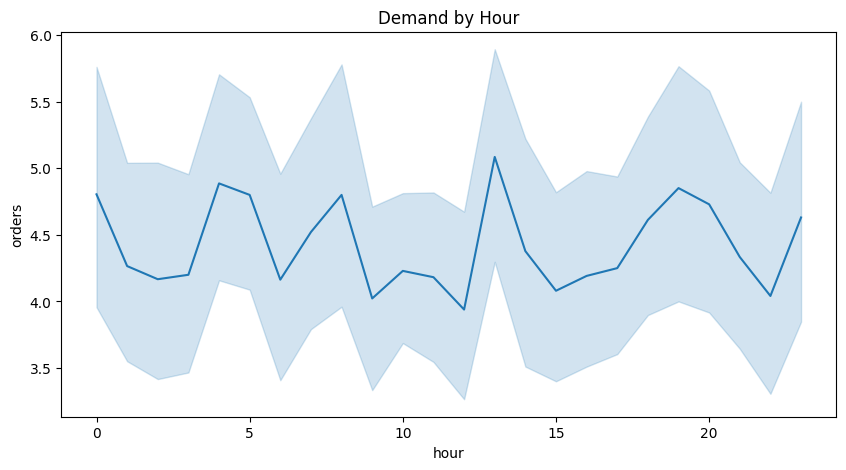

In [10]:
plt.figure(figsize=(10,5))

sns.lineplot(data=demand,x='hour',y='orders')

plt.title("Demand by Hour")
plt.show()

In [11]:
demand.to_csv("../DATA/PROCESSED/hourly_demand.csv",index=False)

In [12]:
top_products = df.groupby('product_name')['quantity'].sum().sort_values(ascending=False).head(10)

top_products

product_name
Pet Treats        473
Toilet Cleaner    430
Dish Soap         397
Vitamins          380
Cough Syrup       373
Lotion            350
Baby Wipes        328
Cat Food          307
Pulses            273
Bread             270
Name: quantity, dtype: int64

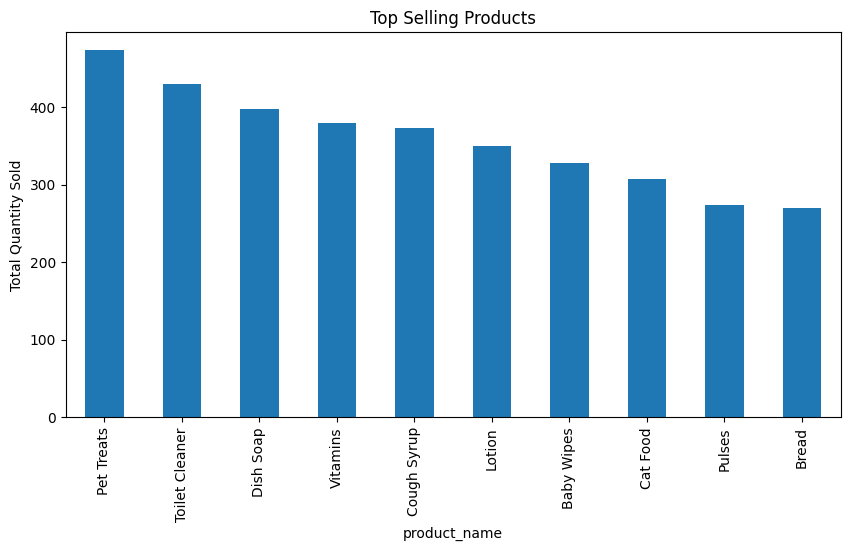

In [13]:
plt.figure(figsize=(10,5))

top_products.plot(kind='bar')

plt.title("Top Selling Products")
plt.ylabel("Total Quantity Sold")

plt.show()

In [14]:
df.columns

Index(['order_id', 'product_id', 'quantity', 'unit_price', 'product_name',
       'category', 'brand', 'price', 'mrp', 'margin_percentage',
       'shelf_life_days', 'min_stock_level', 'max_stock_level', 'customer_id',
       'order_date', 'promised_delivery_time', 'actual_delivery_time',
       'delivery_status', 'order_total', 'payment_method',
       'delivery_partner_id', 'store_id', 'customer_name', 'email', 'phone',
       'address', 'area', 'pincode', 'registration_date', 'customer_segment',
       'total_orders', 'avg_order_value', 'hour', 'day'],
      dtype='str')

In [15]:
area_demand = df.groupby('area').size().sort_values(ascending=False)

area_demand

area
Orai           44
Deoghar        40
Gandhinagar    37
Nandyal        36
Ratlam         35
               ..
Phusro          4
Barasat         4
Raichur         3
Bokaro          2
Mangalore       1
Length: 316, dtype: int64

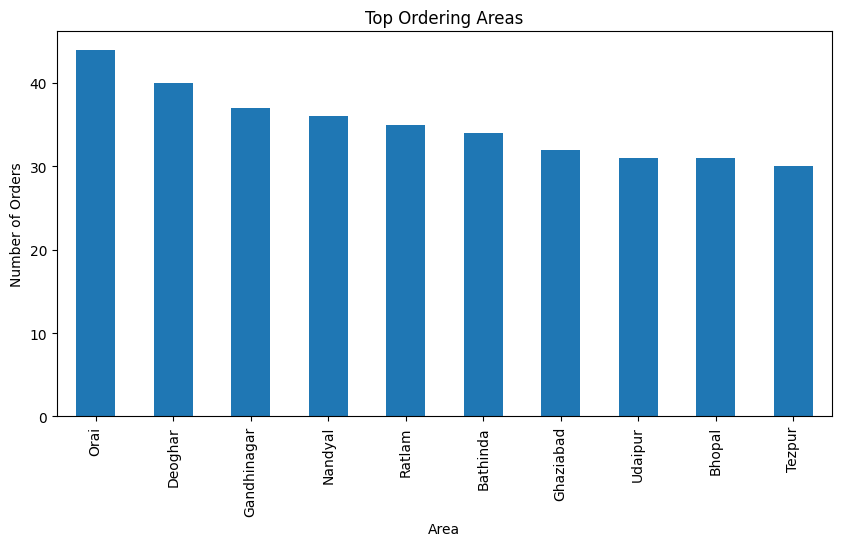

In [16]:
plt.figure(figsize=(10,5))

area_demand.head(10).plot(kind='bar')

plt.title("Top Ordering Areas")
plt.xlabel("Area")
plt.ylabel("Number of Orders")

plt.show()

In [17]:
hourly_orders = df.groupby('hour').size()

hourly_orders

hour
0     221
1     209
2     200
3     189
4     215
5     216
6     204
7     217
8     240
9     181
10    203
11    184
12    193
13    239
14    197
15    204
16    197
17    204
18    226
19    228
20    227
21    195
22    198
23    213
dtype: int64

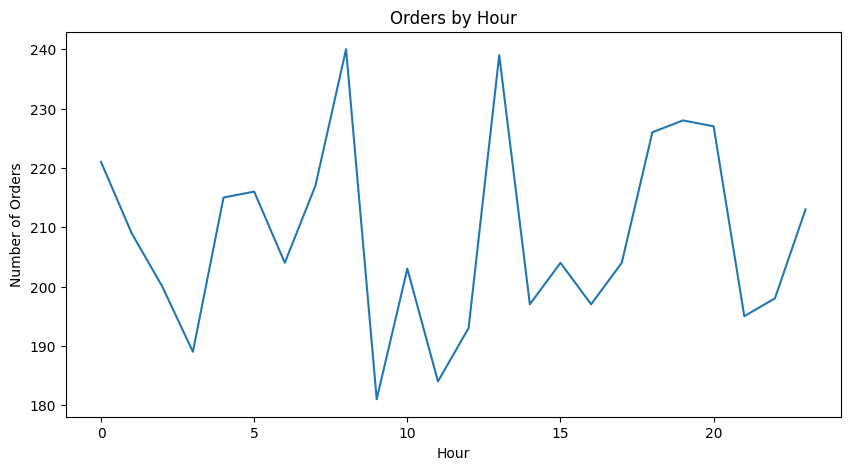

In [18]:
plt.figure(figsize=(10,5))

sns.lineplot(x=hourly_orders.index, y=hourly_orders.values)

plt.title("Orders by Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Orders")

plt.show()

In [19]:
category_sales = df.groupby('category')['quantity'].sum().sort_values(ascending=False)

category_sales.head(10)

category
Dairy & Breakfast        1114
Household Care           1078
Pet Care                 1003
Pharmacy                  973
Fruits & Vegetables       966
Snacks & Munchies         963
Grocery & Staples         895
Personal Care             887
Cold Drinks & Juices      758
Instant & Frozen Food     742
Name: quantity, dtype: int64

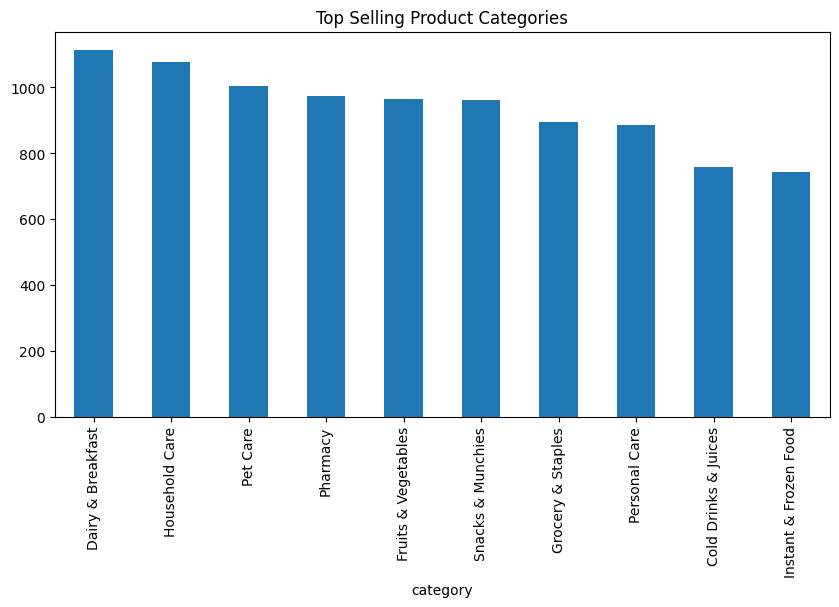

In [20]:
plt.figure(figsize=(10,5))

category_sales.head(10).plot(kind='bar')

plt.title("Top Selling Product Categories")

plt.show()

In [21]:
hourly_orders = df.groupby('hour').size().reset_index(name='orders')

hourly_orders

,hour,orders
0,0,221
1,1,209
2,2,200
3,3,189
4,4,215
5,5,216
6,6,204
7,7,217
8,8,240
9,9,181


In [22]:
from sklearn.model_selection import train_test_split

X = hourly_orders[['hour']]
y = hourly_orders['orders']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [23]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [24]:
predictions = model.predict(X_test)

predictions

array([205.72, 204.27, 205.45, 210.13, 198.58])

In [25]:
model.predict(pd.DataFrame({'hour':[20]}))

array([221.46])